# Logistic Regression (LR) - Supervised Multiclass Task

This pipeline includes data preprocessing, specific for this model, followed by the training and the evaluation of the classifier. The options in terms of data preprocessing and hyperparameters are the same as in the Binary Classification task.

**Results and Discussion:**

- Again, alancing standardization of the data had a positive impact in the results. So we kept both. This can be easly observed by changing the STANDARDIZE and BALANCE variables in the code below. 

- A study similar to the previous one was performed in terms of features, again the best results were obtained with the full set of all complete numerical features, so we kept those, as can be seen in the example below.

- We performed experiments similar to the ones in the previous section and present below the model being trained with the set of hyperparameters that obtained the best results.

DONATION_TYPE                      0
MONTHS_SINCE_ORIGIN                0
IN_HOUSE                           0
MOR_HIT_RATE                       0
MEDIAN_HOME_VALUE                  0
                                  ..
NUMBER_PROM_12_unknown             0
MONTHS_SINCE_LAST_GIFT_unknown     0
MONTHS_SINCE_FIRST_GIFT_unknown    0
FILE_AVG_GIFT_unknown              0
FILE_CARD_GIFT_unknown             0
Length: 71, dtype: int64
Train set score (Accuracy) = 0.575715859030837
Test set score (Accuracy)  = 0.5367464905037159



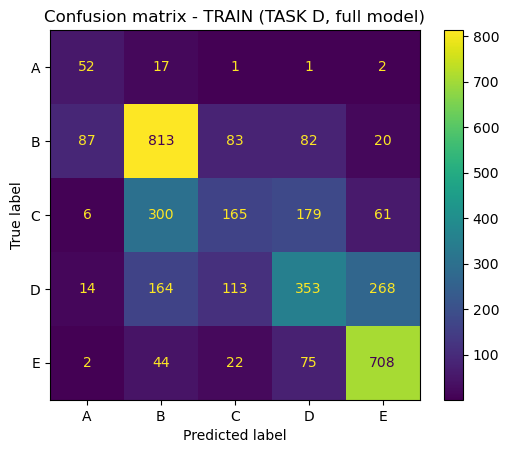

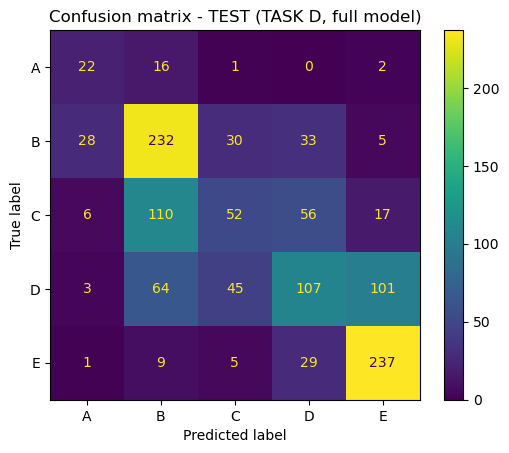


TRAIN classification report (TASK D):
              precision    recall  f1-score   support

           A       0.32      0.71      0.44        73
           B       0.61      0.75      0.67      1085
           C       0.43      0.23      0.30       711
           D       0.51      0.39      0.44       912
           E       0.67      0.83      0.74       851

    accuracy                           0.58      3632
   macro avg       0.51      0.58      0.52      3632
weighted avg       0.56      0.58      0.55      3632

TEST classification report (TASK D):
              precision    recall  f1-score   support

           A       0.37      0.54      0.44        41
           B       0.54      0.71      0.61       328
           C       0.39      0.22      0.28       241
           D       0.48      0.33      0.39       320
           E       0.65      0.84      0.74       281

    accuracy                           0.54      1211
   macro avg       0.49      0.53      0.49      1211
w

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

df_donors = pd.read_csv('Donors_dataset.csv')

STANDARDIZE = False # Should the data be standartized?
BALANCE = True # Should the data be balanced?

def donation_type(amount):
    if amount >= 50:
        return "A"
    elif 20 <= amount < 50:
        return "B"
    elif 13 <= amount < 20:
        return "C"
    elif 10 <= amount < 13:
        return "D"
    else:
        return "E"

num_features = [
    "MONTHS_SINCE_ORIGIN",
    "IN_HOUSE",
    "MOR_HIT_RATE",
    "MEDIAN_HOME_VALUE",
    "MEDIAN_HOUSEHOLD_INCOME",
    "PCT_OWNER_OCCUPIED",
    "PER_CAPITA_INCOME",
    "PCT_ATTRIBUTE1",
    "PCT_ATTRIBUTE2",
    "PCT_ATTRIBUTE3",
    "PCT_ATTRIBUTE4",
    "PEP_STAR",
    "RECENT_STAR_STATUS",
    "FREQUENCY_STATUS_97NK",
    "RECENT_RESPONSE_PROP",
    "RECENT_AVG_GIFT_AMT",
    "RECENT_CARD_RESPONSE_PROP",
    "RECENT_AVG_CARD_GIFT_AMT",
    "RECENT_RESPONSE_COUNT",
    "RECENT_CARD_RESPONSE_COUNT",
    "LIFETIME_CARD_PROM",
    "LIFETIME_PROM",
    "LIFETIME_GIFT_AMOUNT",
    "LIFETIME_GIFT_COUNT",
    "LIFETIME_AVG_GIFT_AMT",
    "LIFETIME_GIFT_RANGE",
    "LIFETIME_MAX_GIFT_AMT",
    "LIFETIME_MIN_GIFT_AMT",
    "LAST_GIFT_AMT",
    "CARD_PROM_12",
    "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT",
    "MONTHS_SINCE_FIRST_GIFT",
    "FILE_AVG_GIFT",
    "FILE_CARD_GIFT"
]

cat_features = [
]

C = 1
penalty = 'l2'
solver = 'liblinear'
max_iter = 100

# Use only rows with non-null TARGET_D and create DONATION_TYPE
df_D = df_donors[df_donors["TARGET_D"].notnull()].copy()
df_D["DONATION_TYPE"] = df_D["TARGET_D"].apply(donation_type)

# Keep only DONATION_TYPE + selected predictors
df_D = df_D[["DONATION_TYPE"] + num_features + cat_features].copy()

# Handle missing numeric features: median + *_unknown flag
for col in num_features:
    df_D[col + "_unknown"] = df_D[col].isna().astype(int)
    median_val = df_D[col].median()
    df_D[col] = df_D[col].fillna(median_val)

# Handle missing categoricals: "Unknown"
for col in cat_features:
    df_D[col] = df_D[col].fillna("Unknown")

# Check missing values
print(df_D.isna().sum())

# One-hot encode categorical variables
df_D_encoded = pd.get_dummies(df_D, columns=cat_features, drop_first=True)

# Final X and y
X_D = df_D_encoded.drop("DONATION_TYPE", axis=1)
y_D = df_D_encoded["DONATION_TYPE"]

X_D_full = X_D.copy()
y_D_full = y_D.copy()

X_D_train, X_D_test, y_D_train, y_D_test = train_test_split(
    X_D_full, y_D_full, random_state=42
)

if STANDARDIZE:
    sc = StandardScaler()
    sc.fit(X_D_train)
    X_train_used = sc.transform(X_D_train)
    X_test_used  = sc.transform(X_D_test)
else:
    X_train_used = X_D_train
    X_test_used  = X_D_test

if BALANCE:
    class_weight = 'balanced'
else:
    class_weight = None

# Fit logistic regression (multi-class via one-vs-rest with liblinear)
logreg_D = LogisticRegression(
    C=C,
    penalty=penalty,
    solver=solver,
    max_iter=max_iter,
    class_weight=class_weight
)
logreg_D.fit(X_train_used, y_D_train)

# Accuracy
print("Train set score (Accuracy) =", logreg_D.score(X_train_used, y_D_train))
print("Test set score (Accuracy)  =", logreg_D.score(X_test_used, y_D_test))
print()

# Predictions
y_D_train_pred = logreg_D.predict(X_train_used)
y_D_test_pred  = logreg_D.predict(X_test_used)

# TRAIN confusion matrix
cm_train_D = confusion_matrix(y_D_train, y_D_train_pred)
disp_train_D = ConfusionMatrixDisplay(confusion_matrix=cm_train_D,
                                      display_labels=logreg_D.classes_)
disp_train_D.plot()
plt.title("Confusion matrix - TRAIN (TASK D, full model)")
plt.show()

# TEST confusion matrix
cm_test_D = confusion_matrix(y_D_test, y_D_test_pred)
disp_test_D = ConfusionMatrixDisplay(confusion_matrix=cm_test_D,
                                     display_labels=logreg_D.classes_)
disp_test_D.plot()
plt.title("Confusion matrix - TEST (TASK D, full model)")
plt.show()

### Evaluation metrics

print("\nTRAIN classification report (TASK D):")
print(classification_report(y_D_train, y_D_train_pred))

print("TEST classification report (TASK D):")
print(classification_report(y_D_test, y_D_test_pred))

y_D_test_probs = logreg_D.predict_proba(X_test_used)

# Calculate Macro AUC for multiclass using One-vs-Rest strategy
auc_test_D = roc_auc_score(
    y_D_test, 
    y_D_test_probs, 
    multi_class='ovr', 
    average='macro',
    labels=logreg_D.classes_
)

print(f"TEST macro AUC (Logistic Regression, TASK D) = {auc_test_D:.4f}")